In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict, deque
import random
from typing import Dict, Tuple, Optional
from pathlib import Path
import gym
import gymnasium
from gym import spaces
from datetime import datetime
import sys
import os
from stable_baselines3 import PPO, SAC, DDPG
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt

In [40]:
# 设置设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 全局参数
NUM_EPISODE = 1500
NUM_STEP = 96
NUM_AGENT = 2  # 设置为2个储能单元示例
WARMUP_EPISODES = NUM_EPISODE // 2
MAX_CHARGE_RATE = 0.2  # 每个储能单元的最大充电功率

LR_ACTOR = 0.001
LR_CRITIC = 0.001
HIDDEN_DIM = 64
GAMMA = 0.99
TAU = 0.01
MEMORY_SIZE = 5000
BATCH_SIZE = 256
TARGET_UPDATE_INTERVAL = 100  # 每100步更新一次
PRINT_INTERVAL = 50
highest_reward = 0

Using device:  cpu


In [38]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, Optional, List
import os
import sys
import matplotlib.pyplot as plt

class SingleAgentEnergyStorageEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    
    def __init__(self,
                 data_path: str = None,
                 num_agents: int = NUM_AGENT,  # 储能单元数量
                 user_type_distribution: Dict[int, int] = {0: 1, 1: 1, 2: 1},
                 episode_length: int = NUM_STEP,
                 battery_capacity: float = 2,
                 max_charge_rate: float = MAX_CHARGE_RATE,
                 efficiency: float = 0.95,
                 init_soc: float = 0.05,
                 seed: Optional[int] = None,
                 reward_type: str = 'profit',
                 verbose: int = 1,
                 output_file: str = "all_agents_data.xlsx"):  # 'profit' or 'cost'
        
        super().__init__()
        
        # 环境参数
        self.user_type_distribution = user_type_distribution
        self.num_agents = num_agents
        self.episode_length = episode_length
        self.battery_capacity = battery_capacity
        self.max_charge_rate = max_charge_rate
        self.efficiency = efficiency
        self.init_soc = init_soc
        self.reward_type = reward_type
        self.verbose = verbose
        self.episode_count = 0
        self.output_file = output_file

        # 创建输出目录（如果需要）
        output_dir = os.path.dirname(output_file)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        
        # 初始化数据存储结构
        self.all_agents_data = {agent_id: [] for agent_id in range(num_agents)}

        # 创建单智能体的观察空间和动作空间
        self.observation_space = self._create_observation_space()
        self.action_space = self._create_action_space()
        
        # 设置随机种子
        self.seed = seed
        self.np_random = np.random.default_rng(seed) if seed else np.random.default_rng()
        
        # 数据加载和处理
        if data_path is None:
            # 尝试从不同位置加载数据
            possible_paths = [
                # Path.cwd() / "data" / "opsd_building.csv",
                # Path(".") / "data" / "opsd_building.csv"
                # Path(".") / "data" / "train_prices.csv"
                Path(".") / "data" / "test_prices.csv"
            ]
            for path in possible_paths:
                if path.exists():
                    data_path = str(path)
                    break
            else:
                raise FileNotFoundError("Data file not found. Please specify data_path.")
        
        self.raw_data = self._load_data(data_path)
        self.normalization_params = self._calculate_normalization_params()
        
        # 初始化历史记录容器
        self._init_history_containers()
        
        # 重置环境
        self.reset()

    def _create_observation_space(self) -> spaces.Box:
        # 每个储能单元有4个特征：时间、电价、负荷、SOC
        # 总观测维度：4 * 储能单元数量
        return spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(4 * self.num_agents,),
            dtype=np.float32
        )
    
    def _create_action_space(self) -> spaces.Box:
        # 每个储能单元一个动作，对应充放电功率
        return spaces.Box(
            low=-self.max_charge_rate,
            high=self.max_charge_rate,
            shape=(self.num_agents,),
            dtype=np.float32
        )
    
    def _load_data(self, data_path: str) -> pd.DataFrame:
        """从CSV文件加载数据"""
        try:
            data = pd.read_csv(data_path)
            print(f"Data loaded successfully from {data_path}")
            return data
        except Exception as e:
            raise ValueError(f"Unable to load data file: {e}")
        
    def _calculate_normalization_params(self) -> Dict[str, float]:
        """计算标准化所需参数"""
        params = {}
        
        # 电价标准化参数 (Z-score)
        prices = self.raw_data.iloc[:, -1].values  # 最后一列是电价
        params['price_mean'] = np.mean(prices)
        params['price_std'] = np.std(prices)
        
        # 负荷标准化参数 (Z-score)
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        all_loads = []
        for col in load_cols:
            if col in self.raw_data.columns:
                all_loads.extend(self.raw_data[col].values)
            else:
                raise ValueError(f"Missing load column: {col}")
        
        params['load_mean'] = np.mean(all_loads)
        params['load_std'] = np.std(all_loads)

        return params
    
    def _process_load_data(self) -> Dict[int, pd.DataFrame]:
        """处理负荷数据并为每个储能单元创建负荷曲线"""
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        price_col = self.raw_data.columns[-1]  # 电价列
        
        num_rows = self.raw_data.shape[0]
        num_days = num_rows // self.episode_length
        
        # 随机选择一天
        # day_idx = self.np_random.integers(0, num_days)
        day_idx = 1
        if day_idx > num_days - 1:
            day_idx = num_days - 1
        
        load_profiles = {}
        for agent_id, col in enumerate(load_cols):
            start = day_idx * self.episode_length
            end = start + self.episode_length
            
            if end > num_rows:
                # 如果数据不够，重复最后一天
                start = (num_days - 1) * self.episode_length
                end = num_rows
            
            # 标准化负荷和电价
            agent_load = (self.raw_data[col].iloc[start:end].values - 
                          self.normalization_params['load_mean']) / self.normalization_params['load_std']
            agent_price = (self.raw_data[price_col].iloc[start:end].values - 
                           self.normalization_params['price_mean']) / self.normalization_params['price_std']
            
            df = pd.DataFrame({
                'period': np.arange(len(agent_load)),
                'load': agent_load,
                'price': agent_price
            })
            load_profiles[agent_id] = df
            
        return load_profiles
    
    def _init_history_containers(self):
        """初始化历史记录容器"""
        self.charge_history = [[] for _ in range(self.num_agents)]
        self.soc_history = [[] for _ in range(self.num_agents)]
        self.reward_history = []
        self.price_history = []
        self.total_actions = []
        self.agent_rewards = [[] for _ in range(self.num_agents)]  # 每个储能单元的奖励历史
        self.agent_actions = [[] for _ in range(self.num_agents)]  # 每个储能单元的动作历史
        self.agent_soc = [[] for _ in range(self.num_agents)]      # 每个储能单元的SOC历史
        self.episode_data = {agent_id: [] for agent_id in range(self.num_agents)}  # 存储每个智能体的数据记录

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None) -> np.ndarray:
        """重置环境到初始状态"""
        if seed is not None:
            self.seed = seed
            self.np_random = np.random.default_rng(seed)
        
        self.current_step = 0
        self.battery_soc = [float(self.init_soc) for _ in range(self.num_agents)]
        self.episode_count += 1  # 增加代数计数器
        # 清空历史记录
        self._init_history_containers()
        
        # 处理负荷数据
        self.load_profiles = self._process_load_data()
        
        # 记录初始SOC
        for agent_id in range(self.num_agents):
            self.soc_history[agent_id].append(self.battery_soc[agent_id])
            self.agent_soc[agent_id].append(self.battery_soc[agent_id])
        
        # 获取初始观察值并拼接
        observations = []
        for agent_id in range(self.num_agents):
            obs = self._get_single_observation(agent_id)
            observations.append(obs)
        flat_obs = np.concatenate(observations)

        # 返回观察值和信息字典
        info = {
            'current_step': self.current_step,
            'soc_history': self.soc_history,
            'charge_history': self.charge_history
        }
        return flat_obs, info

    def _get_single_observation(self, agent_id: int) -> np.ndarray:
        """获取单个储能单元的标准化观察值"""
        time = self.current_step / self.episode_length
        
        # 使用标准化后的数据
        current_price = self.load_profiles[agent_id]['price'].iloc[self.current_step]
        current_load = self.load_profiles[agent_id]['load'].iloc[self.current_step]
        
        # SOC值
        soc_value = float(self.battery_soc[agent_id])
        
        return np.array([time, current_price, current_load, soc_value], dtype=np.float32)

    def step(self, actions: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, dict]:
        """执行一个时间步的环境动态"""
        # 确保动作形状正确
        if actions.shape != (self.num_agents,):
            raise ValueError(f"Invalid action shape: expected {(self.num_agents,)}, got {actions.shape}")
        
        # 记录总动作
        self.total_actions.append(actions.copy())
        
        # 获取当前电价（已标准化）
        current_price = self.load_profiles[0]['price'].iloc[self.current_step]
        real_price = self._denormalize_price(current_price)

        # 记录价格历史
        self.price_history.append(real_price)
        
        # 执行电池动态
        rewards = []
        
        for agent_id in range(self.num_agents):
            action = actions[agent_id]
            self.agent_actions[agent_id].append(action)# 记录动作
            
            # 限制充电功率在允许范围内
            charge_power = np.clip(action, -self.max_charge_rate, self.max_charge_rate)
            # 计算SOC变化
            if charge_power >= 0:
                delta_soc = (charge_power * self.efficiency) / self.battery_capacity
            else:
                delta_soc = (charge_power / self.efficiency) / self.battery_capacity
            
            new_soc = self.battery_soc[agent_id] + delta_soc
            
            # 边界检查和修正
            if new_soc > 0.95:
                available_space = 0.95 - self.battery_soc[agent_id]
                max_chargeable = available_space * self.battery_capacity / self.efficiency
                charge_power = min(charge_power, max_chargeable)
                new_soc = 0.95
                
            if new_soc < 0.05:
                available_energy = self.battery_soc[agent_id] - 0.05
                max_dischargeable = available_energy * self.battery_capacity * self.efficiency
                charge_power = max(charge_power, -max_dischargeable)
                new_soc = 0.05
            
            # 更新电池状态
            self.battery_soc[agent_id] = new_soc
            
            # 记录充电功率和SOC
            self.charge_history[agent_id].append(charge_power)
            self.soc_history[agent_id].append(new_soc)
            self.agent_soc[agent_id].append(new_soc)
            
            # 计算当前时间步的成本/收益
            cost = charge_power * real_price
            self.agent_rewards[agent_id].append(-cost)
            rewards.append(-cost)  # 奖励 = -成本

        # 计算并记录总奖励
        total_reward = sum(rewards)
        self.reward_history.append(total_reward)
        self._record_step_data(actions, rewards, real_price)
        
        # 更新时间步
        self.current_step += 1
        
        # 检查episode是否结束
        done = self.current_step >= self.episode_length - 1
        
        # 获取下一个观察值
        next_observations = []
        for agent_id in range(self.num_agents):
            obs = self._get_single_observation(agent_id)
            next_observations.append(obs)
        flat_obs = np.concatenate(next_observations)
        
        # 构建信息字典
        info = {
            'current_step': self.current_step,
            'soc_history': self.soc_history,
            'charge_history': self.charge_history,
            'price_history': self.price_history,
            'actions': actions.copy(),
            'agent_rewards': self.agent_rewards,
            'agent_actions': self.agent_actions,
            'agent_soc': self.agent_soc
        }
        if self.verbose > 0 and done:
            self._print_episode_summary(info)

        return flat_obs, total_reward, done, done, info
    
    def _denormalize_price(self, normalized_price: float) -> float:
        """将标准化电价反标准化为真实价格"""
        return normalized_price * self.normalization_params['price_std'] + self.normalization_params['price_mean']

    def _denormalize_load(self, normalized_load: float) -> float:
        """将标准化负荷反标准化为真实负荷"""
        return normalized_load * self.normalization_params['load_std'] + self.normalization_params['load_mean']

    def _print_episode_summary(self, info: dict):
        """打印每个储能系统的状态、动作和收益总结"""
        print(f"\nEpisode {self.episode_count},Total Reward: {sum(self.reward_history):.4f}")
        for agent_id in range(self.num_agents):
            print(f"Storage {agent_id},Total Reward: {sum(self.agent_rewards[agent_id]):.4f}")

    def _record_step_data(self, actions: np.ndarray, rewards: List[float], real_price: float):
        """记录当前步骤的数据"""
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        for agent_id in range(self.num_agents):
            # 获取当前状态
            state = self._get_single_observation(agent_id)
            
            # 创建数据记录
            data_record = {
                'episode': self.episode_count,
                'step': self.current_step,
                'timestamp': timestamp,
                'state_time': state[0],
                'state_price': state[1],
                'state_load': state[2],
                'state_soc': state[3],
                'action': actions[agent_id],
                'actual_action': self.charge_history[agent_id][-1],
                'reward': rewards[agent_id],
                'cumulative_reward': sum(self.agent_rewards[agent_id]),
                'soc': self.battery_soc[agent_id],
                'price': real_price,
                'done': (self.current_step >= self.episode_length - 1)
            }
            
            # 添加到智能体的数据记录（当前episode）
            self.episode_data[agent_id].append(data_record)
            
            # 添加到全局数据存储（所有episode）
            self.all_agents_data[agent_id].append(data_record)

    def save_all_data_to_excel(self):
        """将所有智能体的数据保存到Excel文件，每个智能体一个Sheet"""
        if not any(self.all_agents_data.values()):  # 检查是否有数据
            print("No data to save")
            return
        
        # 创建Excel写入器
        with pd.ExcelWriter(self.output_file) as writer:
            for agent_id in range(self.num_agents):
                if self.all_agents_data[agent_id]:  # 检查是否有数据
                    # 创建DataFrame
                    df = pd.DataFrame(self.all_agents_data[agent_id])
                    
                    # 保存到Sheet
                    sheet_name = f"Storage_{agent_id}"
                    df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"All agents data saved to {self.output_file}")

    def close(self):
        """关闭环境并打印总结"""
        self.save_all_data_to_excel()
        avg_soc = np.mean([soc for history in self.soc_history for soc in history])
        print("\nEnvironment Closed")
        print(f"Average SOC across storage units: {avg_soc:.2%}")
        print(f"Total Reward: {sum(self.reward_history):.4f}")

In [6]:
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
 
 
def train_energy_storage():
    print("创建能源存储环境...")
    
    # 创建环境
    env = SingleAgentEnergyStorageEnv(
        num_agents=NUM_AGENT,
        battery_capacity=2.0,
        max_charge_rate=MAX_CHARGE_RATE,
        episode_length=NUM_STEP,
        seed=42
    )
    
    # 包装环境用于Stable Baselines3
    env = Monitor(env)  # 添加监控
    
    # 使用make_vec_env确保环境正确向量化
    vec_env = make_vec_env(
        lambda: env,
        n_envs=1,
        seed=42,
        vec_env_cls=DummyVecEnv
    )
    
    print("创建SAC模型...")
    
    # 创建模型
    model = SAC(
        "MlpPolicy",
        vec_env,
        verbose=1,
        learning_rate=LR_CRITIC,
        buffer_size=MEMORY_SIZE,
        batch_size=BATCH_SIZE,
        gamma=GAMMA,
        tau=TAU,
        device=device,
        tensorboard_log="./energy_storage_tensorboard/"
    )


    # 训练模型
    print(f"开始训练 {NUM_EPISODE} 个回合...")
    model.learn(total_timesteps=NUM_EPISODE * NUM_STEP )
    
    # 保存模型
    model.save("energy_storage_model")
    print("模型保存成功.")
    # 关闭环境
    env.close()
if __name__ == "__main__":
    train_energy_storage()

创建能源存储环境...
Data loaded successfully from data\train_prices.csv
创建SAC模型...
Using cpu device
开始训练 1500 个回合...
Logging to ./energy_storage_tensorboard/SAC_26

Episode 2,Total Reward: -44.4460
Storage 0,Total Reward: -17.0538
Storage 1,Total Reward: -27.3922

Episode 3,Total Reward: 0.3178
Storage 0,Total Reward: 0.0646
Storage 1,Total Reward: 0.2533

Episode 4,Total Reward: -0.0443
Storage 0,Total Reward: 0.0000
Storage 1,Total Reward: -0.0443

Episode 5,Total Reward: 0.7680
Storage 0,Total Reward: 0.7609
Storage 1,Total Reward: 0.0071
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 95       |
|    ep_rew_mean     | -10.9    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 69       |
|    time_elapsed    | 5        |
|    total_timesteps | 380      |
| train/             |          |
|    actor_loss      | -5.63    |
|    critic_loss     | 1.53     |
|    ent_coef        | 0.767    |
|    ent_coef_loss

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: -32.6861
Storage 0,Total Reward: -18.0837
Storage 1,Total Reward: -14.6024
评估完成. 总收益: -32.6861


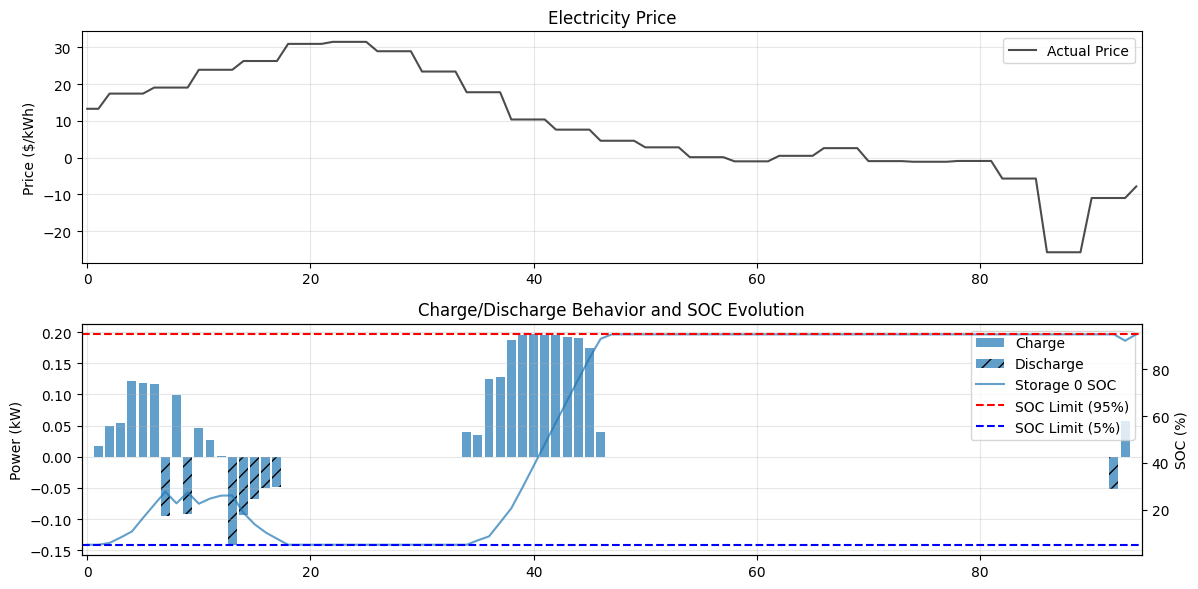

In [42]:
def test_energy_storage(model_path="energy_storage_model"):
    # 加载训练好的模型
    print(f"加载模型: {model_path}")
    model = SAC.load(model_path)
    
    # 创建评估环境
    print("创建评估环境...")
    eval_env = SingleAgentEnergyStorageEnv(
        num_agents=NUM_AGENT,
        battery_capacity=2.0,
        max_charge_rate=MAX_CHARGE_RATE,
        episode_length=NUM_STEP,
        seed=123
    )
    # 使用Monitor包装环境，但保留对原始环境的引用
    monitored_env = Monitor(eval_env)
    
    # 运行评估
    print("开始评估模型...")
    obs, _ = monitored_env.reset()  # 使用包装后的环境
    done = False
    total_reward = 0
    step_count = 0
    
    while not done and step_count < NUM_STEP:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = monitored_env.step(action)
        total_reward += reward
        step_count += 1
    
    print(f"评估完成. 总收益: {total_reward:.4f}")
    
    try:
        import matplotlib.pyplot as plt
        import numpy as np
        
        # 获取数据长度
        num_steps = len(eval_env.price_history)
        # num_agents = eval_env.num_agents
        num_agents=1
        
        # 创建2个子图的布局
        fig, axes = plt.subplots(2, 1, figsize=(12, 6))
        fig.tight_layout(pad=5.0)
        
        # 1. 电价图 (单线)
        ax1 = axes[0]
        ax1.plot(eval_env.price_history, 'k-', label='Actual Price', alpha=0.7)
        ax1.set_ylabel('Price ($/kWh)')
        ax1.set_title('Electricity Price')
        ax1.grid(alpha=0.3)
        ax1.legend()
        
        # 2. 充放电行为和SOC变化 (多代理)
        ax2 = axes[1]
        # 创建第二个Y轴用于SOC
        ax2_soc = ax2.twinx()
        ax2.grid(alpha=0.3)
        
        # 确保所有数据长度一致
        time_steps = np.arange(num_steps)
        
        # 绘制所有代理的充放电柱状图
        for i in range(num_agents):
            # 裁剪SOC历史数据以匹配其他数据的长度
            if len(eval_env.soc_history[i]) > num_steps:
                soc_data = eval_env.soc_history[i][:num_steps]
            else:
                soc_data = eval_env.soc_history[i]
            
            # 只绘制充电部分（正值）
            charge = np.array(eval_env.charge_history[i])
            charge_pos = np.where(charge > 0, charge, 0)
            
            # 只绘制放电部分（负值），转为正值显示
            discharge_pos = np.where(charge < 0, -charge, 0)
            
            # 绘制充电和放电柱状图（堆叠显示）
            if i == 0:
                ax2.bar(time_steps, charge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7, label='Charge')
                ax2.bar(time_steps, -discharge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7, hatch='//', label='Discharge')
            else:
                ax2.bar(time_steps, charge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7)
                ax2.bar(time_steps, -discharge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7, hatch='//')
        
        # 绘制所有代理的SOC折线
        for i in range(num_agents):
            # 确保SOC数据长度与时间步一致
            if len(eval_env.soc_history[i]) > num_steps:
                soc_data = eval_env.soc_history[i][:num_steps]
            else:
                soc_data = eval_env.soc_history[i]
                
            soc_percent = np.array(soc_data) * 100  # 转换为百分比
            ax2_soc.plot(time_steps, soc_percent, 
                        color=f'C{i}', alpha=0.7, linestyle='-',
                        label=f'Storage {i} SOC')
        
        # 添加SOC限制线,上限0.95，下限0.05
        ax2_soc.axhline(y=95, color='r', linestyle='--', label='SOC Limit (95%)')
        ax2_soc.axhline(y=5, color='b', linestyle='--', label='SOC Limit (5%)')
        
        ax2.set_ylabel('Power (kW)')
        ax2_soc.set_ylabel('SOC (%)')
        ax2.set_title('Charge/Discharge Behavior and SOC Evolution')
        ax2.grid(alpha=0.3)
        
        # 合并图例
        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_soc.get_legend_handles_labels()
        # 确保不重复添加SOC限制线标签
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines + lines2, labels + labels2):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax2.legend(unique_lines, unique_labels, loc='upper right')
        
        # 设置相同的x轴范围确保对齐
        ax1.set_xlim(time_steps[0]-0.5, time_steps[-1]+0.5)
        ax2.set_xlim(time_steps[0]-0.5, time_steps[-1]+0.5)
        
        plt.tight_layout()
        plt.savefig('energy_storage_performance.png', dpi=300)
        plt.show()
        
        # 打印性能总结
        # 计算平均SOC（使用裁剪后的数据）
        soc_values = []
        for i in range(num_agents):
            # 确保SOC数据长度匹配
            if len(eval_env.soc_history[i]) > num_steps:
                soc_values.extend(eval_env.soc_history[i][:num_steps])
            else:
                soc_values.extend(eval_env.soc_history[i])
                
        avg_soc = np.mean(soc_values) if soc_values else 0

        
    except ImportError:
        print("无法导入matplotlib，跳过图表生成")
    except Exception as e:
        print(f"可视化过程中发生错误: {str(e)}")
    
    

if __name__ == "__main__":
    test_energy_storage()

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: -32.6861
Storage 0,Total Reward: -18.0837
Storage 1,Total Reward: -14.6024
评估完成. 总收益: -32.6861


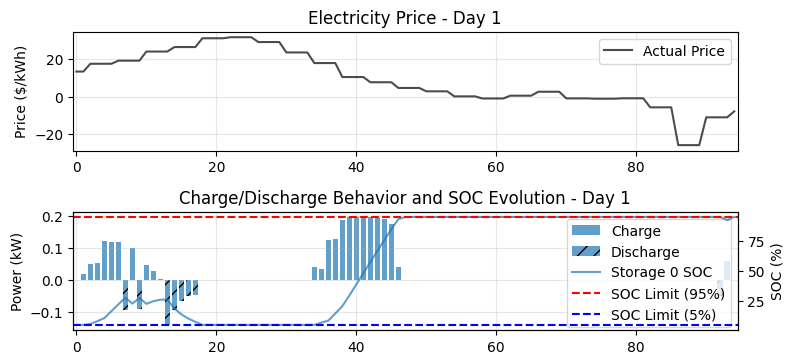

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 92.1853
Storage 0,Total Reward: 44.3182
Storage 1,Total Reward: 47.8670
评估完成. 总收益: 92.1853


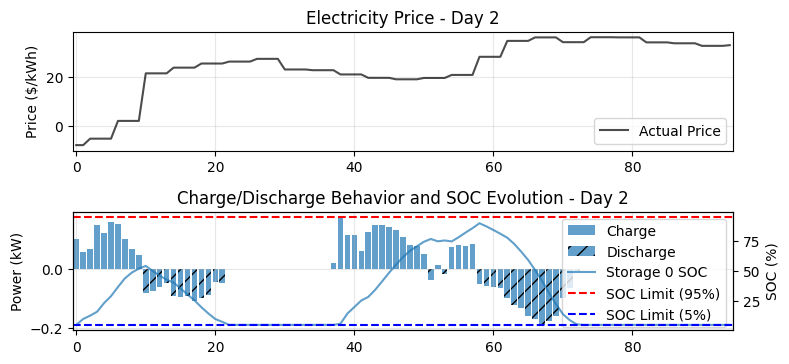

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 30.5212
Storage 0,Total Reward: 12.2189
Storage 1,Total Reward: 18.3023
评估完成. 总收益: 30.5212


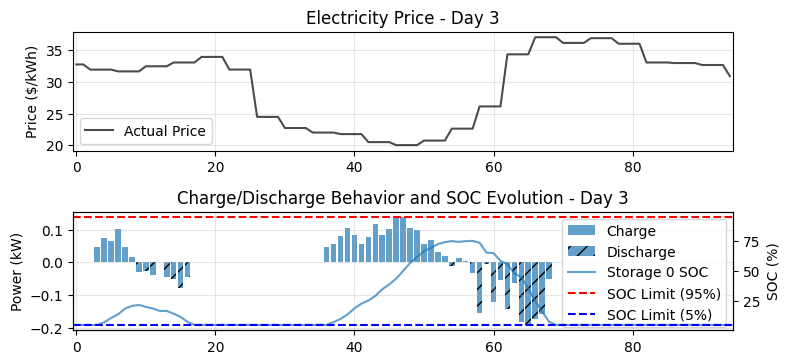

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 30.7496
Storage 0,Total Reward: 12.7934
Storage 1,Total Reward: 17.9562
评估完成. 总收益: 30.7496


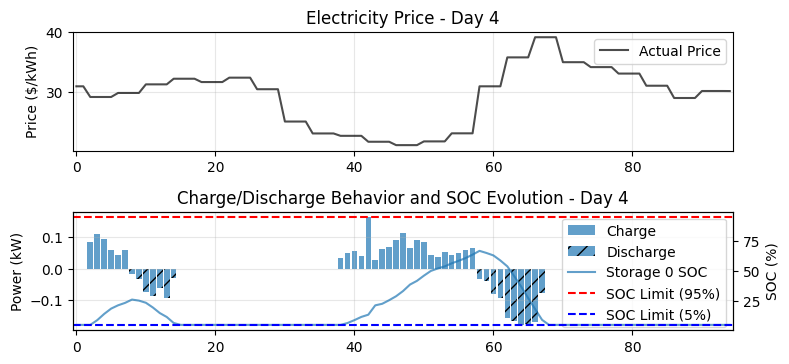

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 0.7212
Storage 0,Total Reward: -0.4168
Storage 1,Total Reward: 1.1380
评估完成. 总收益: 0.7212


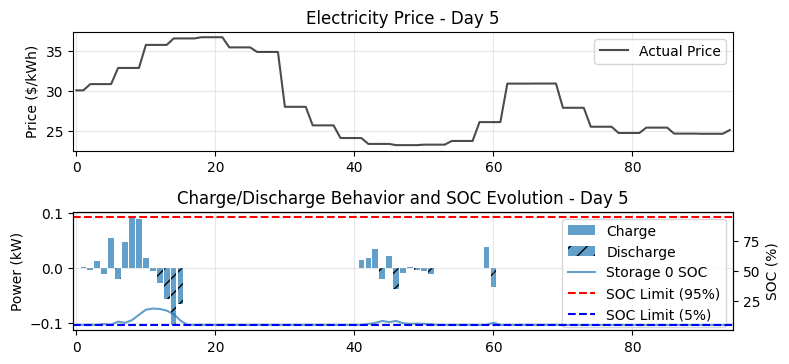

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 23.5646
Storage 0,Total Reward: 4.3152
Storage 1,Total Reward: 19.2494
评估完成. 总收益: 23.5646


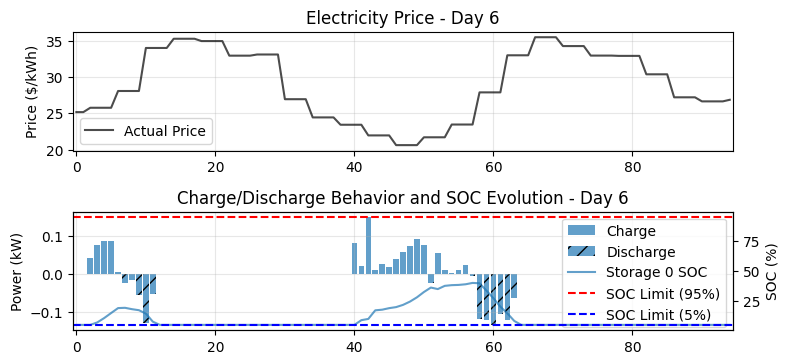

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: -0.1045
Storage 0,Total Reward: -0.8536
Storage 1,Total Reward: 0.7490
评估完成. 总收益: -0.1045


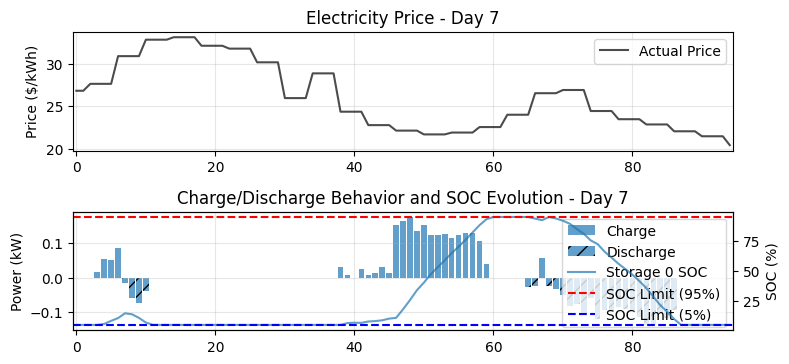

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: -14.5701
Storage 0,Total Reward: -4.3593
Storage 1,Total Reward: -10.2109
评估完成. 总收益: -14.5701


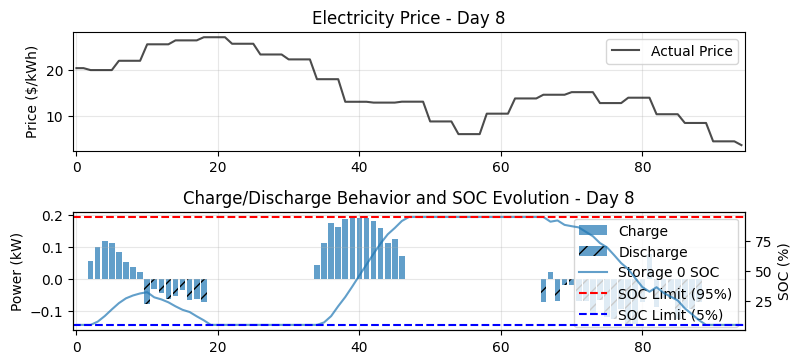

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 76.0772
Storage 0,Total Reward: 32.2120
Storage 1,Total Reward: 43.8651
评估完成. 总收益: 76.0772


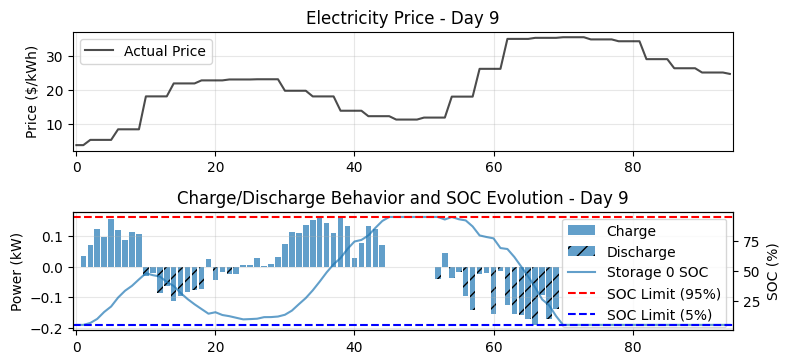

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 43.7909
Storage 0,Total Reward: 21.2011
Storage 1,Total Reward: 22.5898
评估完成. 总收益: 43.7909


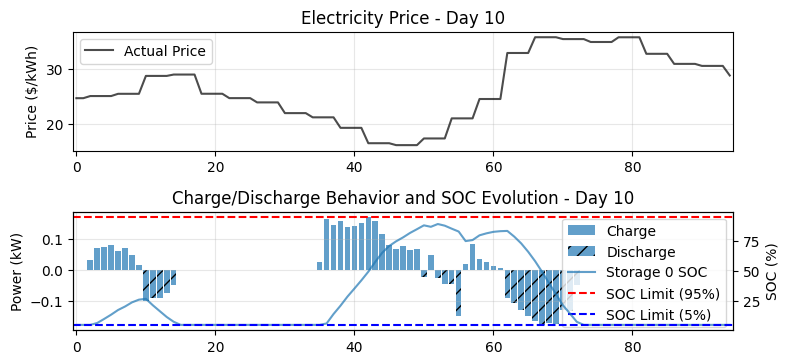

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 51.9206
Storage 0,Total Reward: 22.5453
Storage 1,Total Reward: 29.3753
评估完成. 总收益: 51.9206


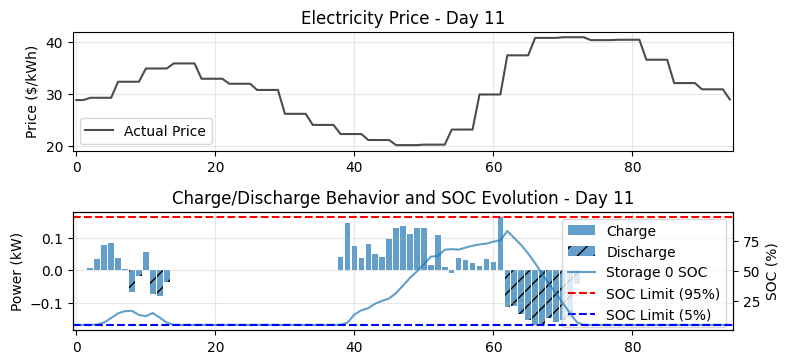

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 46.8571
Storage 0,Total Reward: 21.7078
Storage 1,Total Reward: 25.1492
评估完成. 总收益: 46.8571


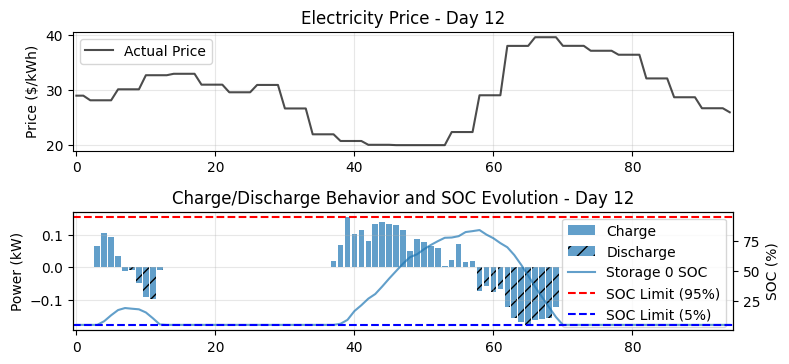

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 41.6759
Storage 0,Total Reward: 15.0474
Storage 1,Total Reward: 26.6285
评估完成. 总收益: 41.6759


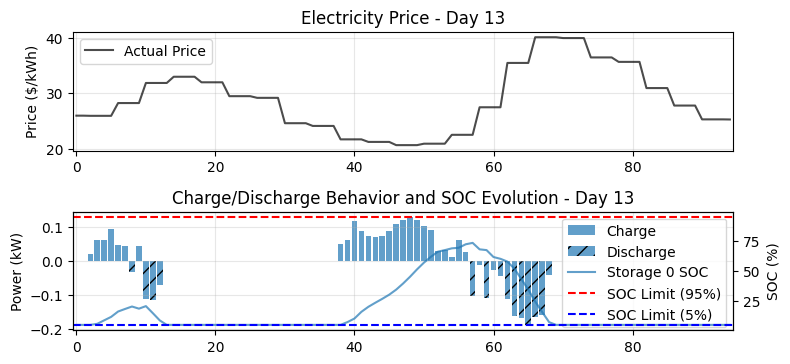

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: 6.9992
Storage 0,Total Reward: -0.3481
Storage 1,Total Reward: 7.3473
评估完成. 总收益: 6.9992


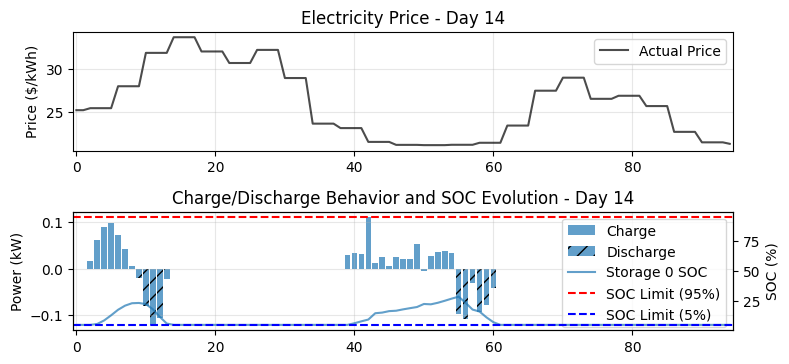

加载模型: energy_storage_model
创建评估环境...
Data loaded successfully from data\test_prices.csv
开始评估模型...

Episode 2,Total Reward: -10.4236
Storage 0,Total Reward: -4.8621
Storage 1,Total Reward: -5.5614
评估完成. 总收益: -10.4236


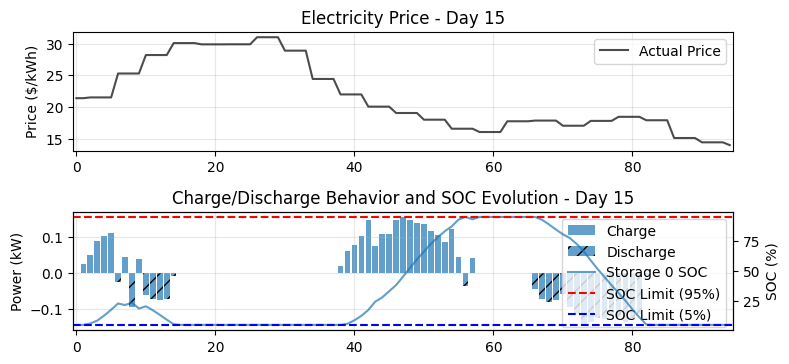


DRL 平均每日总收益: 25.8186


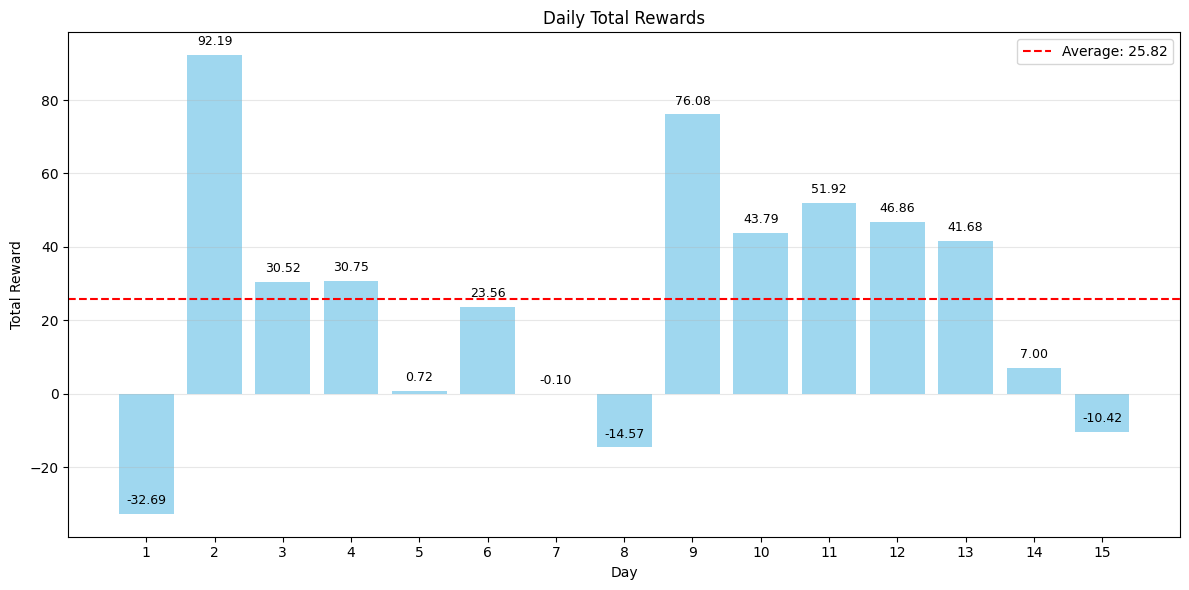


各天的总收益：
Day 1: -32.6861
Day 2: 92.1853
Day 3: 30.5212
Day 4: 30.7496
Day 5: 0.7212
Day 6: 23.5646
Day 7: -0.1045
Day 8: -14.5701
Day 9: 76.0772
Day 10: 43.7909
Day 11: 51.9206
Day 12: 46.8571
Day 13: 41.6759
Day 14: 6.9992
Day 15: -10.4236


In [ ]:
class SingleAgentEnergyStorageEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    
    def __init__(self,
                 data_path: str = None,
                 num_agents: int = NUM_AGENT,  # 储能单元数量
                 user_type_distribution: Dict[int, int] = {0: 1, 1: 1, 2: 1},
                 episode_length: int = NUM_STEP,
                 battery_capacity: float = 2,
                 max_charge_rate: float = MAX_CHARGE_RATE,
                 efficiency: float = 0.95,
                 init_soc: float = 0.05,
                 seed: Optional[int] = None,
                 reward_type: str = 'profit',
                 daynum: int = None,
                 verbose: int = 1,
                 output_file: str = "all_agents_data.xlsx"):  # 'profit' or 'cost'
        
        
        super().__init__()
        
        # 环境参数
        self.user_type_distribution = user_type_distribution
        self.num_agents = num_agents
        self.episode_length = episode_length
        self.battery_capacity = battery_capacity
        self.max_charge_rate = max_charge_rate
        self.efficiency = efficiency
        self.init_soc = init_soc
        self.reward_type = reward_type
        self.verbose = verbose
        self.episode_count = 0
        self.output_file = output_file
        self.daynum= daynum if daynum is not None else 1  # 默认选择第一天

        # 创建输出目录（如果需要）
        output_dir = os.path.dirname(output_file)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        
        # 初始化数据存储结构
        self.all_agents_data = {agent_id: [] for agent_id in range(num_agents)}

        # 创建单智能体的观察空间和动作空间
        self.observation_space = self._create_observation_space()
        self.action_space = self._create_action_space()
        
        # 设置随机种子
        self.seed = seed
        self.np_random = np.random.default_rng(seed) if seed else np.random.default_rng()
        
        # 数据加载和处理
        if data_path is None:
            # 尝试从不同位置加载数据
            possible_paths = [
                # Path.cwd() / "data" / "opsd_building.csv",
                # Path(".") / "data" / "opsd_building.csv"
                # Path(".") / "data" / "train_prices.csv"
                Path(".") / "data" / "test_prices.csv"
            ]
            for path in possible_paths:
                if path.exists():
                    data_path = str(path)
                    break
            else:
                raise FileNotFoundError("Data file not found. Please specify data_path.")
        
        self.raw_data = self._load_data(data_path)
        self.normalization_params = self._calculate_normalization_params()
        
        # 初始化历史记录容器
        self._init_history_containers()
        
        # 重置环境
        self.reset()

    def _create_observation_space(self) -> spaces.Box:
        # 每个储能单元有4个特征：时间、电价、负荷、SOC
        # 总观测维度：4 * 储能单元数量
        return spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(4 * self.num_agents,),
            dtype=np.float32
        )
    
    def _create_action_space(self) -> spaces.Box:
        # 每个储能单元一个动作，对应充放电功率
        return spaces.Box(
            low=-self.max_charge_rate,
            high=self.max_charge_rate,
            shape=(self.num_agents,),
            dtype=np.float32
        )
    
    def _load_data(self, data_path: str) -> pd.DataFrame:
        """从CSV文件加载数据"""
        try:
            data = pd.read_csv(data_path)
            print(f"Data loaded successfully from {data_path}")
            return data
        except Exception as e:
            raise ValueError(f"Unable to load data file: {e}")
        
    def _calculate_normalization_params(self) -> Dict[str, float]:
        """计算标准化所需参数"""
        params = {}
        
        # 电价标准化参数 (Z-score)
        prices = self.raw_data.iloc[:, -1].values  # 最后一列是电价
        params['price_mean'] = np.mean(prices)
        params['price_std'] = np.std(prices)
        
        # 负荷标准化参数 (Z-score)
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        all_loads = []
        for col in load_cols:
            if col in self.raw_data.columns:
                all_loads.extend(self.raw_data[col].values)
            else:
                raise ValueError(f"Missing load column: {col}")
        
        params['load_mean'] = np.mean(all_loads)
        params['load_std'] = np.std(all_loads)

        return params
    
    def _process_load_data(self) -> Dict[int, pd.DataFrame]:
        """处理负荷数据并为每个储能单元创建负荷曲线"""
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        price_col = self.raw_data.columns[-1]  # 电价列
        
        num_rows = self.raw_data.shape[0]
        num_days = num_rows // self.episode_length
        
        # 随机选择一天
        # day_idx = self.np_random.integers(0, num_days)
        day_idx = self.daynum
        if day_idx > num_days - 1:
            day_idx = num_days - 1
        
        load_profiles = {}
        for agent_id, col in enumerate(load_cols):
            start = day_idx * self.episode_length
            end = start + self.episode_length
            
            if end > num_rows:
                # 如果数据不够，重复最后一天
                start = (num_days - 1) * self.episode_length
                end = num_rows
            
            # 标准化负荷和电价
            agent_load = (self.raw_data[col].iloc[start:end].values - 
                          self.normalization_params['load_mean']) / self.normalization_params['load_std']
            agent_price = (self.raw_data[price_col].iloc[start:end].values - 
                           self.normalization_params['price_mean']) / self.normalization_params['price_std']
            
            df = pd.DataFrame({
                'period': np.arange(len(agent_load)),
                'load': agent_load,
                'price': agent_price
            })
            load_profiles[agent_id] = df
            
        return load_profiles
    
    def _init_history_containers(self):
        """初始化历史记录容器"""
        self.charge_history = [[] for _ in range(self.num_agents)]
        self.soc_history = [[] for _ in range(self.num_agents)]
        self.reward_history = []
        self.price_history = []
        self.total_actions = []
        self.agent_rewards = [[] for _ in range(self.num_agents)]  # 每个储能单元的奖励历史
        self.agent_actions = [[] for _ in range(self.num_agents)]  # 每个储能单元的动作历史
        self.agent_soc = [[] for _ in range(self.num_agents)]      # 每个储能单元的SOC历史
        self.episode_data = {agent_id: [] for agent_id in range(self.num_agents)}  # 存储每个智能体的数据记录

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None) -> np.ndarray:
        """重置环境到初始状态"""
        if seed is not None:
            self.seed = seed
            self.np_random = np.random.default_rng(seed)
        
        self.current_step = 0
        self.battery_soc = [float(self.init_soc) for _ in range(self.num_agents)]
        self.episode_count += 1  # 增加代数计数器
        # 清空历史记录
        self._init_history_containers()
        
        # 处理负荷数据
        self.load_profiles = self._process_load_data()
        
        # 记录初始SOC
        for agent_id in range(self.num_agents):
            self.soc_history[agent_id].append(self.battery_soc[agent_id])
            self.agent_soc[agent_id].append(self.battery_soc[agent_id])
        
        # 获取初始观察值并拼接
        observations = []
        for agent_id in range(self.num_agents):
            obs = self._get_single_observation(agent_id)
            observations.append(obs)
        flat_obs = np.concatenate(observations)

        # 返回观察值和信息字典
        info = {
            'current_step': self.current_step,
            'soc_history': self.soc_history,
            'charge_history': self.charge_history
        }
        return flat_obs, info

    def _get_single_observation(self, agent_id: int) -> np.ndarray:
        """获取单个储能单元的标准化观察值"""
        time = self.current_step / self.episode_length
        
        # 使用标准化后的数据
        current_price = self.load_profiles[agent_id]['price'].iloc[self.current_step]
        current_load = self.load_profiles[agent_id]['load'].iloc[self.current_step]
        
        # SOC值
        soc_value = float(self.battery_soc[agent_id])
        
        return np.array([time, current_price, current_load, soc_value], dtype=np.float32)

    def step(self, actions: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, dict]:
        """执行一个时间步的环境动态"""
        # 确保动作形状正确
        if actions.shape != (self.num_agents,):
            raise ValueError(f"Invalid action shape: expected {(self.num_agents,)}, got {actions.shape}")
        
        # 记录总动作
        self.total_actions.append(actions.copy())
        
        # 获取当前电价（已标准化）
        current_price = self.load_profiles[0]['price'].iloc[self.current_step]
        real_price = self._denormalize_price(current_price)

        # 记录价格历史
        self.price_history.append(real_price)
        
        # 执行电池动态
        rewards = []
        
        for agent_id in range(self.num_agents):
            action = actions[agent_id]
            self.agent_actions[agent_id].append(action)# 记录动作
            
            # 限制充电功率在允许范围内
            charge_power = np.clip(action, -self.max_charge_rate, self.max_charge_rate)
            # 计算SOC变化
            if charge_power >= 0:
                delta_soc = (charge_power * self.efficiency) / self.battery_capacity
            else:
                delta_soc = (charge_power / self.efficiency) / self.battery_capacity
            
            new_soc = self.battery_soc[agent_id] + delta_soc
            
            # 边界检查和修正
            if new_soc > 0.95:
                available_space = 0.95 - self.battery_soc[agent_id]
                max_chargeable = available_space * self.battery_capacity / self.efficiency
                charge_power = min(charge_power, max_chargeable)
                new_soc = 0.95
                
            if new_soc < 0.05:
                available_energy = self.battery_soc[agent_id] - 0.05
                max_dischargeable = available_energy * self.battery_capacity * self.efficiency
                charge_power = max(charge_power, -max_dischargeable)
                new_soc = 0.05
            
            # 更新电池状态
            self.battery_soc[agent_id] = new_soc
            
            # 记录充电功率和SOC
            self.charge_history[agent_id].append(charge_power)
            self.soc_history[agent_id].append(new_soc)
            self.agent_soc[agent_id].append(new_soc)
            
            # 计算当前时间步的成本/收益
            cost = charge_power * real_price
            self.agent_rewards[agent_id].append(-cost)
            rewards.append(-cost)  # 奖励 = -成本

        # 计算并记录总奖励
        total_reward = sum(rewards)
        self.reward_history.append(total_reward)
        self._record_step_data(actions, rewards, real_price)
        
        # 更新时间步
        self.current_step += 1
        
        # 检查episode是否结束
        done = self.current_step >= self.episode_length - 1
        
        # 获取下一个观察值
        next_observations = []
        for agent_id in range(self.num_agents):
            obs = self._get_single_observation(agent_id)
            next_observations.append(obs)
        flat_obs = np.concatenate(next_observations)
        
        # 构建信息字典
        info = {
            'current_step': self.current_step,
            'soc_history': self.soc_history,
            'charge_history': self.charge_history,
            'price_history': self.price_history,
            'actions': actions.copy(),
            'agent_rewards': self.agent_rewards,
            'agent_actions': self.agent_actions,
            'agent_soc': self.agent_soc
        }
        if self.verbose > 0 and done:
            self._print_episode_summary(info)

        return flat_obs, total_reward, done, done, info
    
    def _denormalize_price(self, normalized_price: float) -> float:
        """将标准化电价反标准化为真实价格"""
        return normalized_price * self.normalization_params['price_std'] + self.normalization_params['price_mean']

    def _denormalize_load(self, normalized_load: float) -> float:
        """将标准化负荷反标准化为真实负荷"""
        return normalized_load * self.normalization_params['load_std'] + self.normalization_params['load_mean']

    def _print_episode_summary(self, info: dict):
        """打印每个储能系统的状态、动作和收益总结"""
        print(f"\nEpisode {self.episode_count},Total Reward: {sum(self.reward_history):.4f}")
        for agent_id in range(self.num_agents):
            print(f"Storage {agent_id},Total Reward: {sum(self.agent_rewards[agent_id]):.4f}")

    def _record_step_data(self, actions: np.ndarray, rewards: List[float], real_price: float):
        """记录当前步骤的数据"""
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        for agent_id in range(self.num_agents):
            # 获取当前状态
            state = self._get_single_observation(agent_id)
            
            # 创建数据记录
            data_record = {
                'episode': self.episode_count,
                'step': self.current_step,
                'timestamp': timestamp,
                'state_time': state[0],
                'state_price': state[1],
                'state_load': state[2],
                'state_soc': state[3],
                'action': actions[agent_id],
                'actual_action': self.charge_history[agent_id][-1],
                'reward': rewards[agent_id],
                'cumulative_reward': sum(self.agent_rewards[agent_id]),
                'soc': self.battery_soc[agent_id],
                'price': real_price,
                'done': (self.current_step >= self.episode_length - 1)
            }
            
            # 添加到智能体的数据记录（当前episode）
            self.episode_data[agent_id].append(data_record)
            
            # 添加到全局数据存储（所有episode）
            self.all_agents_data[agent_id].append(data_record)

    def save_all_data_to_excel(self):
        """将所有智能体的数据保存到Excel文件，每个智能体一个Sheet"""
        if not any(self.all_agents_data.values()):  # 检查是否有数据
            print("No data to save")
            return
        
        # 创建Excel写入器
        with pd.ExcelWriter(self.output_file) as writer:
            for agent_id in range(self.num_agents):
                if self.all_agents_data[agent_id]:  # 检查是否有数据
                    # 创建DataFrame
                    df = pd.DataFrame(self.all_agents_data[agent_id])
                    
                    # 保存到Sheet
                    sheet_name = f"Storage_{agent_id}"
                    df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"All agents data saved to {self.output_file}")

    def close(self):
        """关闭环境并打印总结"""
        self.save_all_data_to_excel()
        avg_soc = np.mean([soc for history in self.soc_history for soc in history])
        print("\nEnvironment Closed")
        print(f"Average SOC across storage units: {avg_soc:.2%}")
        print(f"Total Reward: {sum(self.reward_history):.4f}")


def test_energy_storage(daynum, model_path="energy_storage_model"):
    # 加载训练好的模型
    print(f"加载模型: {model_path}")
    model = SAC.load(model_path)
    
    # 创建评估环境
    print("创建评估环境...")
    eval_env = SingleAgentEnergyStorageEnv(
        num_agents=NUM_AGENT,
        battery_capacity=2.0,
        max_charge_rate=MAX_CHARGE_RATE,
        episode_length=NUM_STEP,
        seed=123,
        daynum = daynum
    )
    # 使用Monitor包装环境，但保留对原始环境的引用
    monitored_env = Monitor(eval_env)
    
    # 运行评估
    print("开始评估模型...")
    obs, _ = monitored_env.reset()  # 使用包装后的环境
    done = False
    total_reward = 0
    step_count = 0
    
    while not done and step_count < NUM_STEP:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = monitored_env.step(action)
        total_reward += reward
        step_count += 1
    
    print(f"评估完成. 总收益: {total_reward:.4f}")
    
    try:
        import matplotlib.pyplot as plt
        import numpy as np
        
        # 获取数据长度
        num_steps = len(eval_env.price_history)
        # num_agents = eval_env.num_agents
        num_agents = 1
        
        # 创建2个子图的布局
        fig, axes = plt.subplots(2, 1, figsize=(8, 4))
        fig.tight_layout(pad=5.0)
        
        # 1. 电价图 (单线)
        ax1 = axes[0]
        ax1.plot(eval_env.price_history, 'k-', label='Actual Price', alpha=0.7)
        ax1.set_ylabel('Price ($/kWh)')
        ax1.set_title(f'Electricity Price - Day {daynum}')
        ax1.grid(alpha=0.3)
        ax1.legend()
        
        # 2. 充放电行为和SOC变化 (多代理)
        ax2 = axes[1]
        # 创建第二个Y轴用于SOC
        ax2_soc = ax2.twinx()
        ax2.grid(alpha=0.3)
        
        # 确保所有数据长度一致
        time_steps = np.arange(num_steps)
        
        # 绘制所有代理的充放电柱状图
        for i in range(num_agents):
            # 裁剪SOC历史数据以匹配其他数据的长度
            if len(eval_env.soc_history[i]) > num_steps:
                soc_data = eval_env.soc_history[i][:num_steps]
            else:
                soc_data = eval_env.soc_history[i]
            
            # 只绘制充电部分（正值）
            charge = np.array(eval_env.charge_history[i])
            charge_pos = np.where(charge > 0, charge, 0)
            
            # 只绘制放电部分（负值），转为正值显示
            discharge_pos = np.where(charge < 0, -charge, 0)
            
            # 绘制充电和放电柱状图（堆叠显示）
            if i == 0:
                ax2.bar(time_steps, charge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7, label='Charge')
                ax2.bar(time_steps, -discharge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7, hatch='//', label='Discharge')
            else:
                ax2.bar(time_steps, charge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7)
                ax2.bar(time_steps, -discharge_pos, width=0.8, 
                        color=f'C{i}', alpha=0.7, hatch='//')
        
        # 绘制所有代理的SOC折线
        for i in range(num_agents):
            # 确保SOC数据长度与时间步一致
            if len(eval_env.soc_history[i]) > num_steps:
                soc_data = eval_env.soc_history[i][:num_steps]
            else:
                soc_data = eval_env.soc_history[i]
                
            soc_percent = np.array(soc_data) * 100  # 转换为百分比
            ax2_soc.plot(time_steps, soc_percent, 
                        color=f'C{i}', alpha=0.7, linestyle='-',
                        label=f'Storage {i} SOC')
        
        # 添加SOC限制线,上限0.95，下限0.05
        ax2_soc.axhline(y=95, color='r', linestyle='--', label='SOC Limit (95%)')
        ax2_soc.axhline(y=5, color='b', linestyle='--', label='SOC Limit (5%)')
        
        ax2.set_ylabel('Power (kW)')
        ax2_soc.set_ylabel('SOC (%)')
        ax2.set_title(f'Charge/Discharge Behavior and SOC Evolution - Day {daynum}')
        ax2.grid(alpha=0.3)
        
        # 合并图例
        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_soc.get_legend_handles_labels()
        # 确保不重复添加SOC限制线标签
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines + lines2, labels + labels2):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax2.legend(unique_lines, unique_labels, loc='upper right')
        
        # 设置相同的x轴范围确保对齐
        ax1.set_xlim(time_steps[0]-0.5, time_steps[-1]+0.5)
        ax2.set_xlim(time_steps[0]-0.5, time_steps[-1]+0.5)
        
        plt.tight_layout()
        plt.savefig(f'energy_storage_performance_day_{daynum}.png', dpi=300)
        plt.show()
    
    except ImportError:
        print("无法导入matplotlib，跳过图表生成")
    except Exception as e:
        print(f"可视化过程中发生错误: {str(e)}")
    
    return total_reward

def plot_daily_rewards(rewards):
    """绘制各天的总收益柱状图"""
    try:
        import matplotlib.pyplot as plt
        import numpy as np
        
        days = list(range(1, len(rewards)))
        daily_rewards = rewards[1:]
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(days, daily_rewards, color='skyblue', alpha=0.8)
        
        # 添加平均值线
        avg_reward = np.mean(daily_rewards)
        plt.axhline(avg_reward, color='r', linestyle='--', label=f'Average: {avg_reward:.2f}')
        
        # 在柱状图上添加数值标签
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + max(daily_rewards)*0.02,
                     f"{height:.2f}", ha='center', va='bottom', fontsize=9)
        
        plt.title('Daily Total Rewards')
        plt.xlabel('Day')
        plt.ylabel('Total Reward')
        plt.xticks(days)
        plt.grid(axis='y', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('daily_rewards_summary.png', dpi=300)
        plt.show()
        
    except ImportError:
        print("无法导入matplotlib，跳过图表生成")
    except Exception as e:
        print(f"绘制每日收益图时出错: {str(e)}")

if __name__ == "__main__":
    DAY = 16
    rewards = np.zeros(DAY)  # 索引0不使用，从1开始
    
    # 运行所有天的评估
    for daynum in range(1, DAY):
        rewards[daynum] = test_energy_storage(daynum)
    
    # 计算DRL总收益（平均）
    DRL_total_reward = np.mean(rewards[1:])
    print(f"\nDRL 平均每日总收益: {DRL_total_reward:.4f}")
    
    # 绘制各天的总收益柱状图
    plot_daily_rewards(rewards)
    
    # 打印各天的总收益
    print("\n各天的总收益：")
    for daynum in range(1, DAY):
        print(f"Day {daynum}: {rewards[daynum]:.4f}")